Problema 1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data/surveyDataSience.csv", low_memory=False)
df = df.iloc[1:].reset_index(drop=True)

print(df.shape)
print(df.head())

(25973, 369)
  Time from Start to Finish (seconds)     Q1   Q2         Q3  \
0                                 910  50-54  Man      India   
1                                 784  50-54  Man  Indonesia   
2                                 924  22-24  Man   Pakistan   
3                                 575  45-49  Man     Mexico   
4                                 781  45-49  Man      India   

                  Q4                       Q5          Q6 Q7_Part_1 Q7_Part_2  \
0  Bachelor’s degree                    Other  5-10 years    Python         R   
1    Master’s degree  Program/Project Manager   20+ years       NaN       NaN   
2    Master’s degree        Software Engineer   1-3 years    Python       NaN   
3    Doctoral degree       Research Scientist   20+ years    Python       NaN   
4    Doctoral degree                    Other   < 1 years    Python       NaN   

  Q7_Part_3  ... Q38_B_Part_3 Q38_B_Part_4   Q38_B_Part_5 Q38_B_Part_6  \
0       NaN  ...          NaN          Na

In [4]:
#1) Numarul de respondenti
n_resp = len(df)
print("Numar respondenti:", n_resp)

Numar respondenti: 25973


In [5]:
#2) Număr si tipul informațiilor (atribute) pentru un respondent
print("Număr atribute (coloane):", df.shape[1])
print(df.columns)
print(df.dtypes)


Număr atribute (coloane): 369
Index(['Time from Start to Finish (seconds)', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5',
       'Q6', 'Q7_Part_1', 'Q7_Part_2', 'Q7_Part_3',
       ...
       'Q38_B_Part_3', 'Q38_B_Part_4', 'Q38_B_Part_5', 'Q38_B_Part_6',
       'Q38_B_Part_7', 'Q38_B_Part_8', 'Q38_B_Part_9', 'Q38_B_Part_10',
       'Q38_B_Part_11', 'Q38_B_OTHER'],
      dtype='object', length=369)
Time from Start to Finish (seconds)    object
Q1                                     object
Q2                                     object
Q3                                     object
Q4                                     object
                                        ...  
Q38_B_Part_8                           object
Q38_B_Part_9                           object
Q38_B_Part_10                          object
Q38_B_Part_11                          object
Q38_B_OTHER                            object
Length: 369, dtype: object


In [6]:
#3) Numarul de respondenți cu date complete
complete_all = df.dropna().shape[0]
print("Complet pe TOATE cele 369 coloane:", complete_all)

Complet pe TOATE cele 369 coloane: 0


In [7]:
#4) Durata medie a studiilor superioare (ani)
def edu_years(x):
    if pd.isna(x): return np.nan
    if "Bachelor" in x: return 3
    if "Master" in x: return 5
    if "Doctoral" in x: return 8
    if "Professional doctorate" in x: return 8
    if "Some college" in x: return 1.5
    if "No formal education" in x: return 0
    if "I prefer not" in x: return np.nan
    return np.nan

df["edu_years"] = df["Q4"].apply(edu_years)

mean_all = df["edu_years"].mean()
mean_ro = df.loc[df["Q3"]=="Romania", "edu_years"].mean()
mean_ro_w = df.loc[(df["Q3"]=="Romania") & (df["Q2"]=="Woman"), "edu_years"].mean()

print("Media ani studii (toți):", mean_all)
print("Media ani studii (România):", mean_ro)
print("Media ani studii (România, femei):", mean_ro_w)

Media ani studii (toți): 4.269845340487651
Media ani studii (România): 4.758333333333334
Media ani studii (România, femei): 5.34375


In [8]:
#5) Numărul de respondenți femei din România cu date complete
complete_all_w = df.loc[(df["Q3"]=="Romania") & (df["Q2"]=="Woman")].dropna()
print("Femei România cu date complete:", len(complete_all_w))

Femei România cu date complete: 0


In [9]:
#6) Femei din România care programează în Python / C++ + intervalul de vârstă dominant
lang_cols = [c for c in df.columns if c.startswith("Q7_Part_")]

def uses_language(sub_df, lang):
    return sub_df[lang_cols].eq(lang).any(axis=1)

rom_w = df[(df["Q3"]=="Romania") & (df["Q2"]=="Woman")].copy()
rom_w["uses_python"] = uses_language(rom_w, "Python")
rom_w["uses_cpp"] = uses_language(rom_w, "C++")

n_py = rom_w["uses_python"].sum()
n_cpp = rom_w["uses_cpp"].sum()

print("Femei RO care folosesc Python:", n_py)
print("Femei RO care folosesc C++:", n_cpp)

# Interval vârstă cu cele mai multe
top_age_py = rom_w.loc[rom_w["uses_python"], "Q1"].value_counts()
top_age_cpp = rom_w.loc[rom_w["uses_cpp"], "Q1"].value_counts()

print("\nDistribuție vârstă (Python):\n", top_age_py)
print("\nDistribuție vârstă (C++):\n", top_age_cpp)

if len(top_age_py)>0:
    print("\nVârsta dominantă Python:", top_age_py.idxmax())
if len(top_age_cpp)>0:
    print("Vârsta dominantă C++:", top_age_cpp.idxmax())

Femei RO care folosesc Python: 12
Femei RO care folosesc C++: 4

Distribuție vârstă (Python):
 Q1
35-39    5
22-24    3
25-29    2
18-21    1
40-44    1
Name: count, dtype: int64

Distribuție vârstă (C++):
 Q1
18-21    1
25-29    1
22-24    1
35-39    1
Name: count, dtype: int64

Vârsta dominantă Python: 35-39
Vârsta dominantă C++: 18-21


In [10]:
# 7) Domeniul de valori posibile + extreme pentru fiecare atribut
def analyze_attribute_ranges(df):
    attribute_summary = {}
    for col in df.columns:
        unique_values = df[col].dropna().unique()
        num_unique_values = len(unique_values)
        try:
            numeric_values = pd.to_numeric(df[col].dropna(), errors='coerce')
            min_val, max_val = numeric_values.min(), numeric_values.max()
        except:
            min_val, max_val = None, None
        attribute_summary[col] = {
            "Număr de valori posibile": num_unique_values,
            "Minim": min_val,
            "Maxim": max_val,
            "Exemple de valori": unique_values[:5]
        }
    return pd.DataFrame.from_dict(attribute_summary, orient='index')
attribute_summary_df = analyze_attribute_ranges(df)
print(attribute_summary_df.head(30))

                                     Număr de valori posibile  Minim  \
Time from Start to Finish (seconds)                      4421  120.0   
Q1                                                         11    NaN   
Q2                                                          5    NaN   
Q3                                                         66    NaN   
Q4                                                          7    NaN   
Q5                                                         15    NaN   
Q6                                                          7    NaN   
Q7_Part_1                                                   1    NaN   
Q7_Part_2                                                   1    NaN   
Q7_Part_3                                                   1    NaN   
Q7_Part_4                                                   1    NaN   
Q7_Part_5                                                   1    NaN   
Q7_Part_6                                                   1   

In [11]:
#8). Transformarea vechimii în programare și analiza statistică
map_q6 = {
    "I have never written code": 0,
    "< 1 years": 0.5,
    "1-3 years": 2,
    "3-5 years": 4,
    "5-10 years": 7.5,
    "10-20 years": 15,
    "20+ years": 25
}

df["code_years"] = df["Q6"].map(map_q6)

stats = {
    "min": df["code_years"].min(),
    "max": df["code_years"].max(),
    "mean": df["code_years"].mean(),
    "std": df["code_years"].std(),
    "median": df["code_years"].median(),
}
print(stats)

{'min': np.float64(0.0), 'max': np.float64(25.0), 'mean': np.float64(5.281061101913526), 'std': np.float64(6.79090316922895), 'median': np.float64(2.0)}


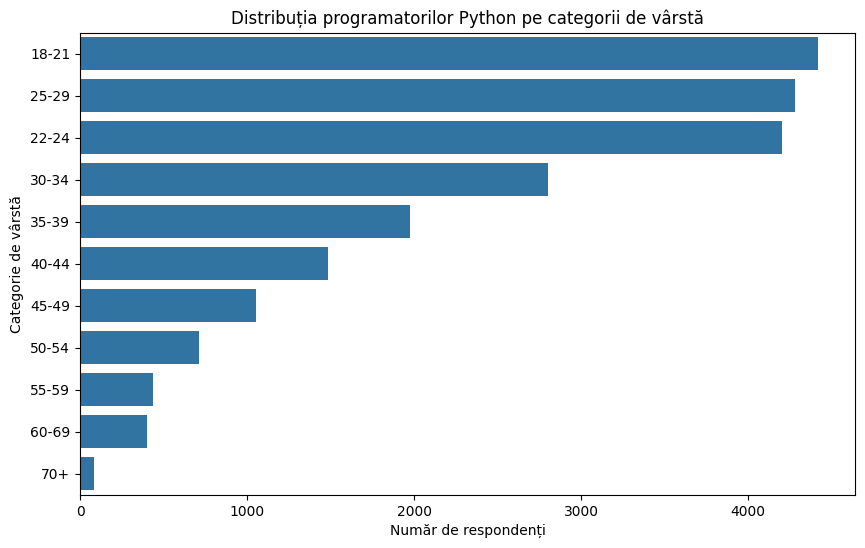

In [12]:
#9).distributia respondentilor care programeaza in Python pe categorii de varsta
def plot_python_age_distribution(df, title):
    plt.figure(figsize=(10, 6))
    sns.countplot(y=df["Q1"], order=df["Q1"].value_counts().index)
    plt.xlabel("Număr de respondenți")
    plt.ylabel("Categorie de vârstă")
    plt.title(title)
    plt.show()

python_users = df[df["Q7_Part_1"] == "Python"]
plot_python_age_distribution(python_users, "Distribuția programatorilor Python pe categorii de vârstă")

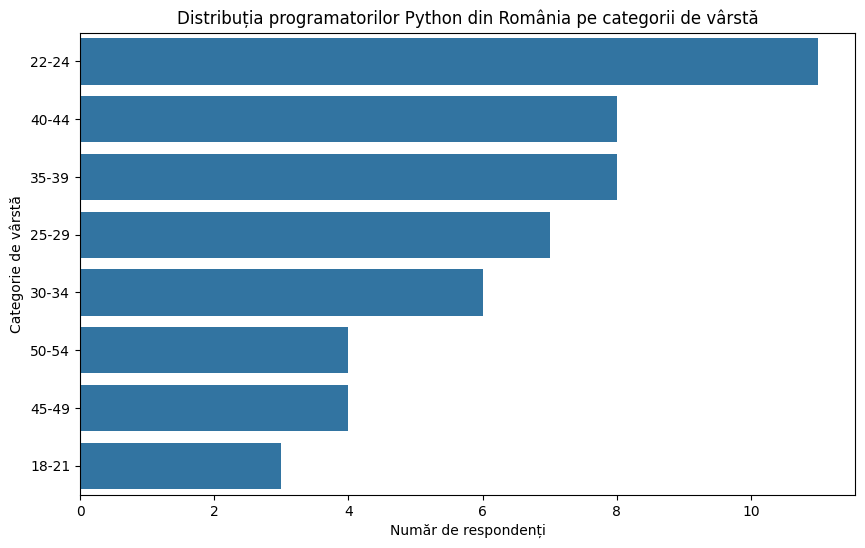

In [13]:
#10).distributia respondentilor din Romania care programeaza in Python pe categorii de varsta
romania_python_users = python_users[python_users["Q3"] == "Romania"]
plot_python_age_distribution(romania_python_users, "Distribuția programatorilor Python din România pe categorii de vârstă")

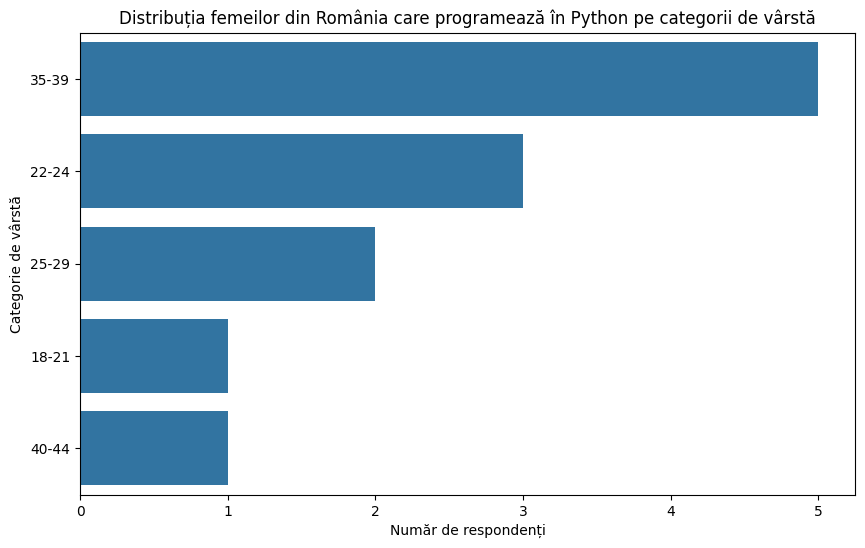

In [14]:
#11).distributia respondentilor femei din Romania care programeaza in Python pe categorii de varsta
romania_women_python_users = romania_python_users[romania_python_users["Q2"] == "Woman"]
plot_python_age_distribution(romania_women_python_users, "Distribuția femeilor din România care programează în Python pe categorii de vârstă")

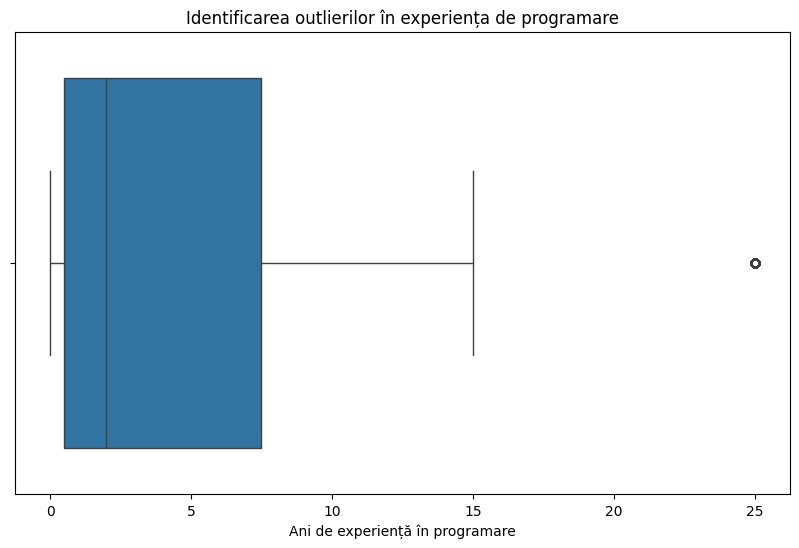

In [15]:
def plot_outliers_experience(df):
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df["code_years"])
    plt.xlabel("Ani de experiență în programare")
    plt.title("Identificarea outlierilor în experiența de programare")
    plt.show()

#12).respondentii care pot fi considerati "outlieri" din punct de vedere al vechimii in programare (puteti folositi un boxplot pentru a identifica aceste valori)
exp_map = {
    "I have never written code": 0,
    "< 1 years": 0.5,
    "1-3 years": 2,
    "3-5 years": 4,
    "5-10 years": 7.5,
    "10-20 years": 15,
    "20+ years": 25
}

df["code_years"] = df["Q6"].map(exp_map)

plot_outliers_experience(df)

Problema 2

In [47]:
from PIL import Image,ImageFilter
import random
import os

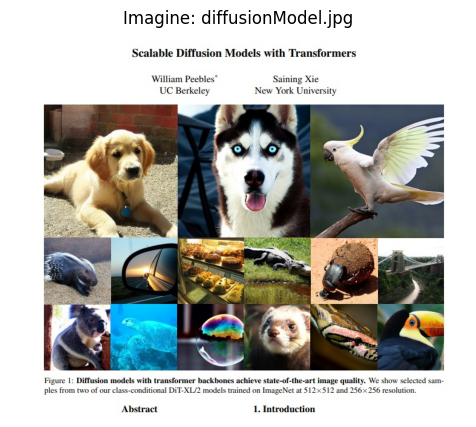

In [48]:
images = [file for file in os.listdir("data/images") if file.lower().endswith(('.png', '.jpg', '.jpeg','.webp',))]
imgNo = random.randint(0,11)
img_path = os.path.join("data/images", images[imgNo])
img = Image.open(img_path)
plt.figure(figsize=(6, 5))
plt.imshow(img)
plt.title(f"Imagine: {images[imgNo]}")
plt.axis('off')
plt.show()

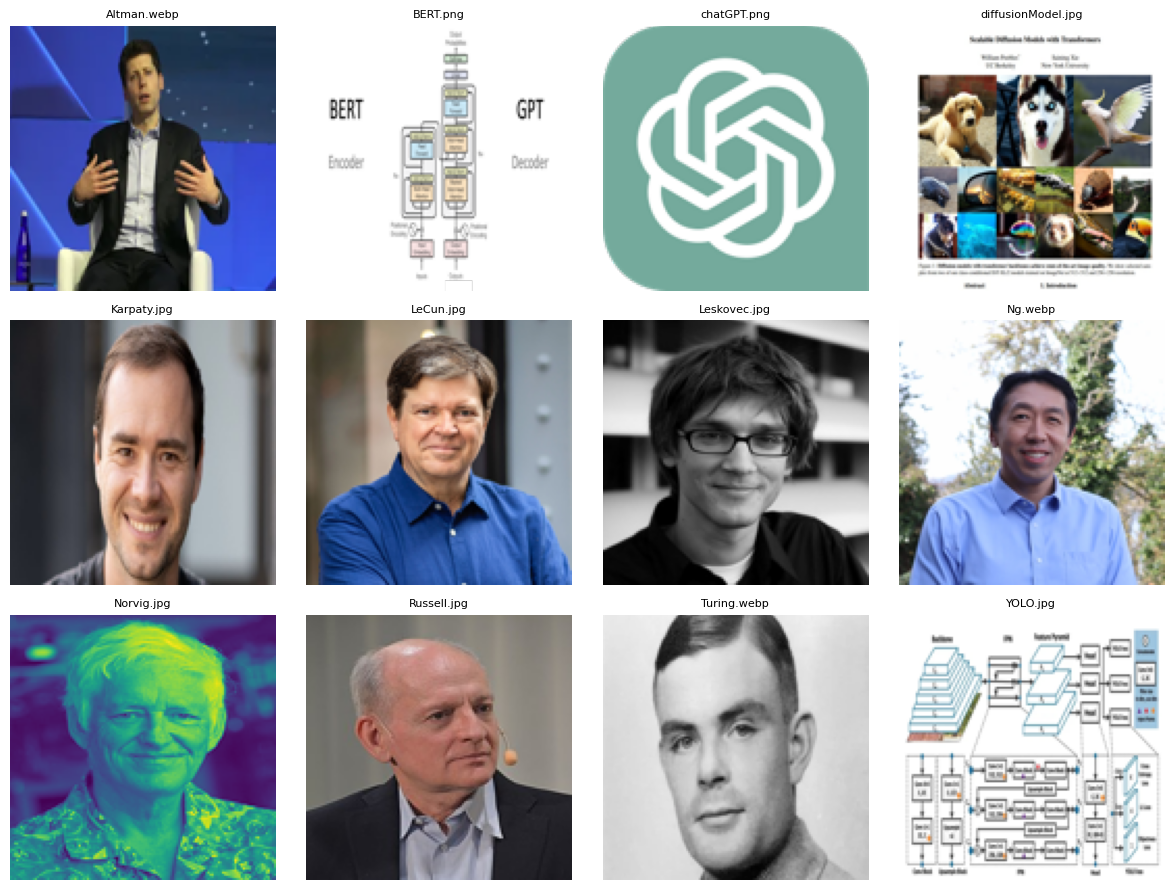

In [49]:
def plot_images_grid(images, cols=4,gray=False):
    rows = (len(images) + cols - 1) // cols

    plt.figure(figsize=(cols*3, rows*3))
    for i, (filename, img) in enumerate(images):
        plt.subplot(rows, cols, i+1)
        if gray:
            plt.imshow(img, cmap='gray')
        else:
            plt.imshow(img)
        plt.axis('off')
        plt.title(filename, fontsize=8)
    plt.tight_layout()
    plt.show()

resized_images = []
for file in images:
    img_path = os.path.join("data/images",file)
    img = Image.open(img_path)
    img_resized = img.resize((128,128))
    resized_images.append((file,img_resized))

plot_images_grid(resized_images)

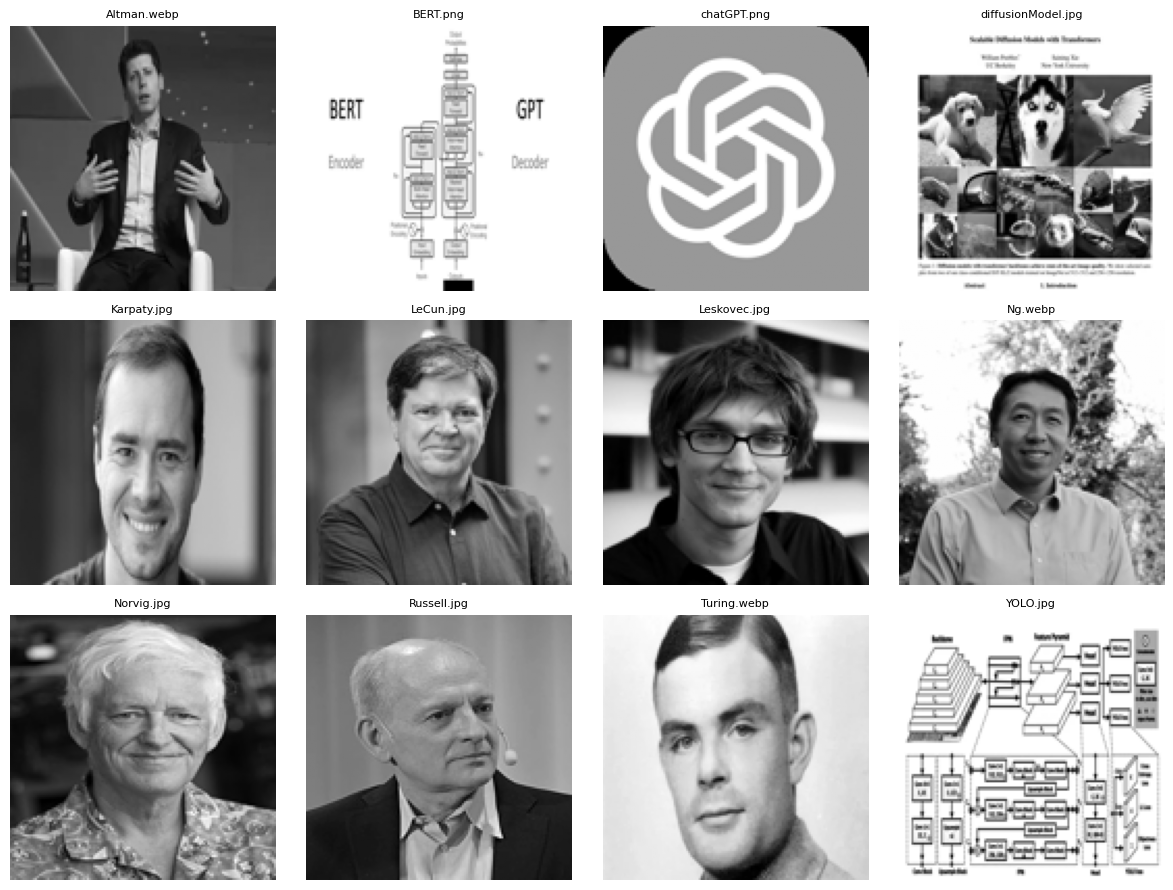

In [50]:
resized_gray_images = []
for file in images:
    img_path = os.path.join("data/images", file)
    img = Image.open(img_path).convert('L')
    img_resized = img.resize((128, 128))
    resized_gray_images.append((file, img_resized))

plot_images_grid(resized_gray_images,gray=True)

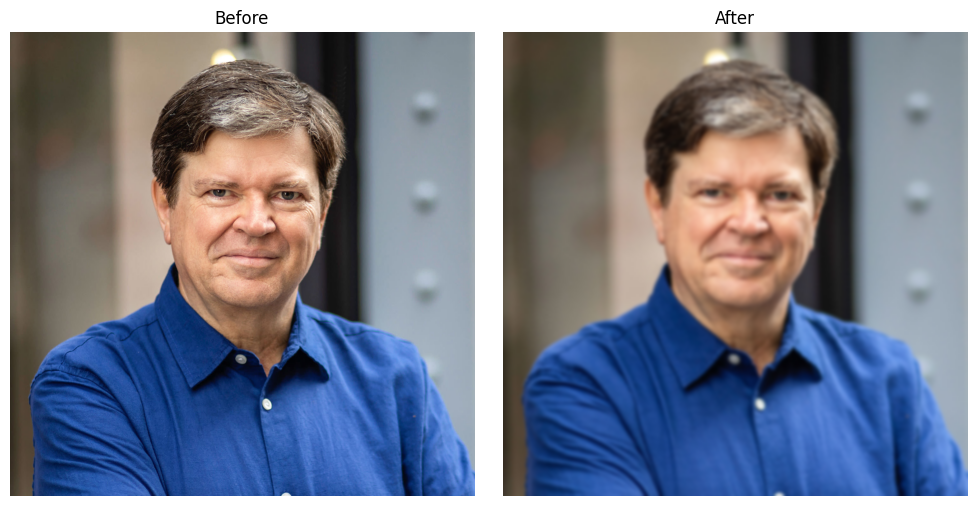

In [51]:
imgNo = random.randint(0,11)
img_path = os.path.join("data/images", images[imgNo])
img = Image.open(img_path)
blurred_img = img.filter(ImageFilter.GaussianBlur(radius = 5))

plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.axis('off')
plt.title("Before")

plt.subplot(1, 2, 2)
plt.imshow(blurred_img)
plt.axis('off')
plt.title("After")

plt.tight_layout()
plt.show()

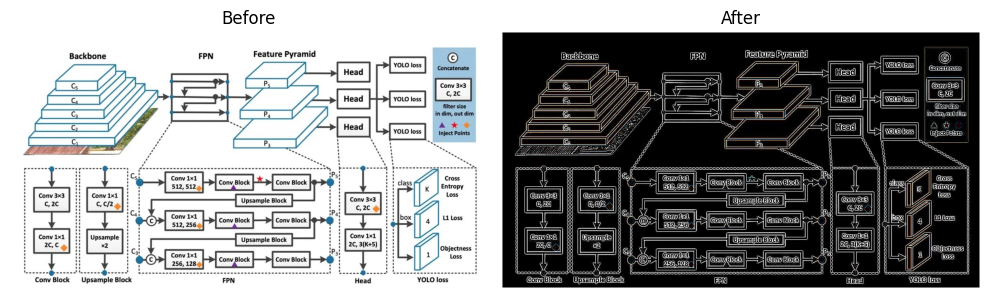

In [52]:
imgNo = random.randint(0,11)
img_path = os.path.join("data/images", "YOLO.jpg")

original_img = Image.open(img_path)

edges_img = original_img.filter(ImageFilter.FIND_EDGES)

plt.figure(figsize=(10,5))

plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.axis('off')
plt.title("Before")

plt.subplot(1, 2, 2)
plt.imshow(edges_img,cmap="gray")
plt.axis('off')
plt.title("After")

plt.tight_layout()
plt.show()

Problema 3

In [32]:
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import wordnet
from collections import Counter
import unicodedata

In [33]:
with open("data/texts.txt", "r", encoding="utf-8") as f:
    text = f.read()

In [34]:
sentences = sent_tokenize(text)
num_sentences = len(sentences)
print("Numar de propozitii:", num_sentences)

Numar de propozitii: 10


In [35]:
words = word_tokenize(text)
num_words = len(words)
print("Numar de cuvinte:", num_words)

Numar de cuvinte: 187


In [36]:
unique_words = set(words)
num_unique_words = len(unique_words)
print("Numar de cuvinte diferite:", num_unique_words)

Numar de cuvinte diferite: 103


In [37]:
words_alpha = [w for w in words if w.isalpha()]
shortest_word = min(words_alpha, key=len)
longest_word = max(words_alpha, key=len)
print("Cel mai scurt cuvant:", shortest_word)
print("Cel mai lung cuvant:", longest_word)

Cel mai scurt cuvant: o
Cel mai lung cuvant: Confiiiiiiiiiiiiiiiiiiiiiiiiiiiirm


In [38]:
text_no_diacritics = ''.join(
    c for c in unicodedata.normalize('NFD', text) 
    if unicodedata.category(c) != 'Mn'
)
print("Text fara diacritice:\n", text_no_diacritics)

Text fara diacritice:
 Mesaj de informare: 
Cursul si laboratoarele de Inteligenta Artificiala vor fi o 
provocare pentru toti. Suntem convinsi ca veti realiza proiecte 
foarte interesante. Va incurajam sa adresati intrebari atunci 
cand ceva nu e clar, atat in mod live, cat si folosind platforma 
Teams, canalul ”general”. 
Daca ati citit pana aici, va rugam sa lasati un mesaj pe canalul 
general cu textul ”Confiiiiiiiiiiiiiiiiiiiiiiiiiiiirm ca am citit 
textul pentru problema 3 din lab2”. 
--
Mesaj de informare generat de ChatGPT:
Stimati cursanti,
Suntem incantati sa va avem in echipa noastra pentru Cursul si 
laboratoarele de Inteligenta Artificiala. Aceasta experienta va 
fi o adevarata provocare, dar suntem convinsi ca veti realiza 
proiecte extrem de interesante.
Va incurajam sa fiti activi si sa adresati intrebari atunci cand 
ceva nu este clar. Fie ca este vorba de o discutie in timp real 
sau prin intermediul platformei Teams, canalul ”general”, suntem 
aici sa va sprijinim.
S

In [40]:
synonyms = set()
for syn in wordnet.synsets(longest_word,lang='ron'):
    for lemma in syn.lemmas():
        synonyms.add(lemma.name())

print("Sinonime pentru cel mai lung cuvant:", synonyms)

Sinonime pentru cel mai lung cuvant: set()


Problema 4

In [41]:
import math

Normalizare - Problema 1

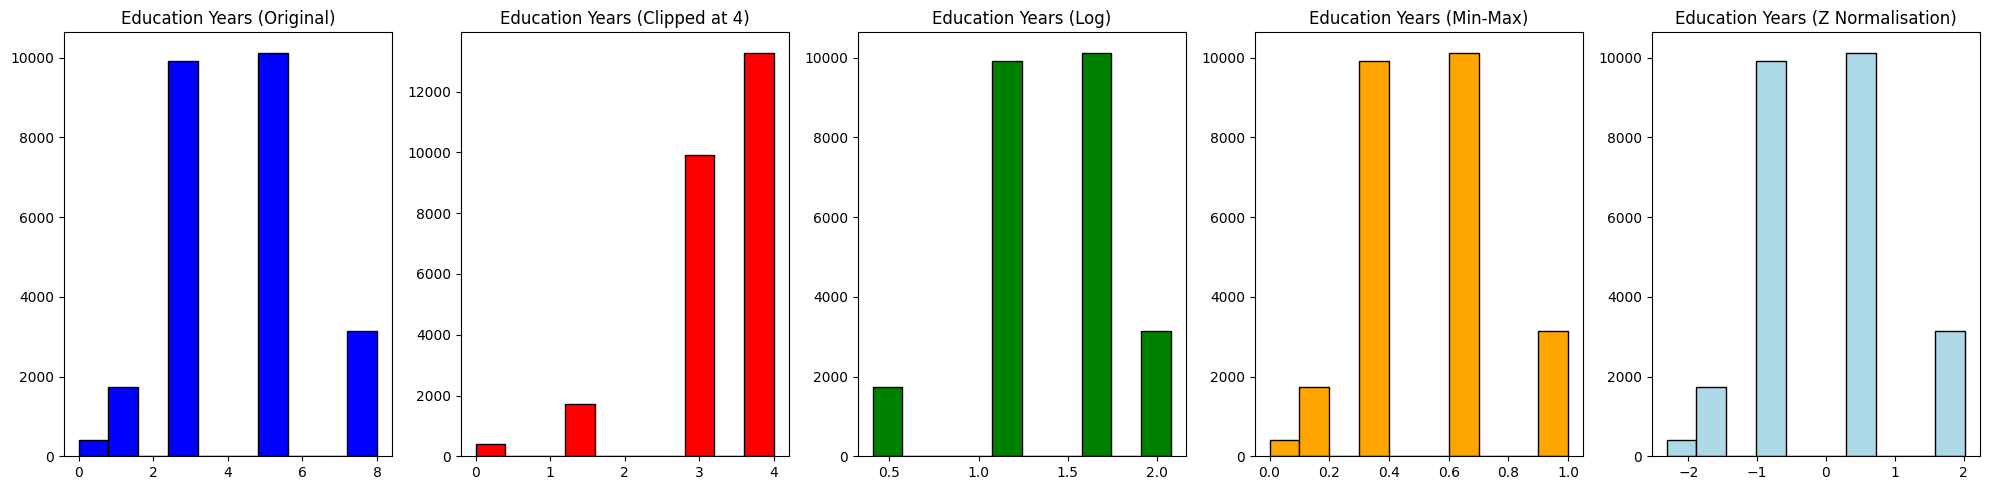

In [42]:
eduYearsClipped = [min(ey, 4) if not np.isnan(ey) else np.nan for ey in df['edu_years']]

eduYearsLog = [math.log(ey) if not np.isnan(ey) and ey > 0 else np.nan for ey in df['edu_years']]

eduYearsSeries = df['edu_years'].dropna()
minVal = eduYearsSeries.min()
maxVal = eduYearsSeries.max()

if maxVal != minVal:
    eduYearsScaled01 = [(ey - minVal) / (maxVal - minVal) if not np.isnan(ey) else np.nan for ey in df['edu_years']]
else:
    eduYearsScaled01 = [0 if not np.isnan(ey) else np.nan for ey in df['edu_years']]

eduYearsScaled01Clean = [ey for ey in eduYearsScaled01 if not np.isnan(ey)]

eduYearsSeries = df['edu_years'].dropna()
mean_val = eduYearsSeries.mean()
std_val = eduYearsSeries.std()

eduYearsZ = [(ey - mean_val) / std_val if not np.isnan(ey) else np.nan for ey in df['edu_years']]

eduYearsZClean = [ey for ey in eduYearsZ if not np.isnan(ey)]

fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(20,5))

ax1.hist(df['edu_years'].dropna(),color='blue', edgecolor='black')
ax1.set_title('Education Years (Original)')

ax2.hist([ey for ey in eduYearsClipped if not np.isnan(ey)], color='red', edgecolor='black')
ax2.set_title('Education Years (Clipped at 4)')

ax3.hist([ey for ey in eduYearsLog if not np.isnan(ey)], color='green', edgecolor='black')
ax3.set_title('Education Years (Log)')

ax4.hist([ey for ey in eduYearsScaled01Clean if not np.isnan(ey)], color='orange', edgecolor='black')
ax4.set_title('Education Years (Min-Max)')

ax5.hist([ey for ey in eduYearsZClean if not np.isnan(ey)], color='lightblue', edgecolor='black')
ax5.set_title('Education Years (Z Normalisation)')

plt.tight_layout()
plt.show()

Normalizare - Problema 2

In [43]:
folder = "data/images"

file_names = [file for file in os.listdir(folder) 
          if file.lower().endswith(('.png', '.jpg', '.jpeg', '.webp'))]

images = []
for file in file_names:
    img = Image.open(os.path.join(folder,file))
    images.append(img)

for img in images:
    pixels = np.array(img, dtype=np.float32)

    mu = pixels.mean()
    sigma = pixels.std() + 1e-8

    pixels_std = (pixels - mu) / sigma

    print(pixels_std)

[[[-0.63536537 -0.54261893  1.018613  ]
  [-0.63536537 -0.54261893  1.018613  ]
  [-0.6199076  -0.51170343  1.0340706 ]
  ...
  [-0.91360474 -0.5889922  -0.20254864]
  [-0.91360474 -0.5889922  -0.20254864]
  [-0.91360474 -0.5889922  -0.20254864]]

 [[-0.63536537 -0.54261893  1.018613  ]
  [-0.63536537 -0.54261893  1.018613  ]
  [-0.6199076  -0.51170343  1.0340706 ]
  ...
  [-0.91360474 -0.5889922  -0.20254864]
  [-0.91360474 -0.5889922  -0.20254864]
  [-0.91360474 -0.5889922  -0.20254864]]

 [[-0.63536537 -0.54261893  1.018613  ]
  [-0.63536537 -0.54261893  1.018613  ]
  [-0.6199076  -0.51170343  1.0340706 ]
  ...
  [-0.91360474 -0.5889922  -0.20254864]
  [-0.91360474 -0.5889922  -0.20254864]
  [-0.91360474 -0.5889922  -0.20254864]]

 ...

 [[-0.40349928 -0.01705574  1.5132606 ]
  [-0.40349928 -0.01705574  1.5132606 ]
  [-0.40349928 -0.01705574  1.5132606 ]
  ...
  [-1.0063512  -0.7590273   0.7403736 ]
  [-1.0372666  -0.74356955  0.7403736 ]
  [-1.0527244  -0.7281118   0.7403736 ]]

 [

Normalizare - Problema 3

Dacă ați citit până aici, vă rugăm să lăsați un mesaj pe canalul 
general cu textul ”Confiiiiiiiiiiiiiiiiiiiiiiiiiiiirm că am citit 
textul pentru problema 3 din lab2”.


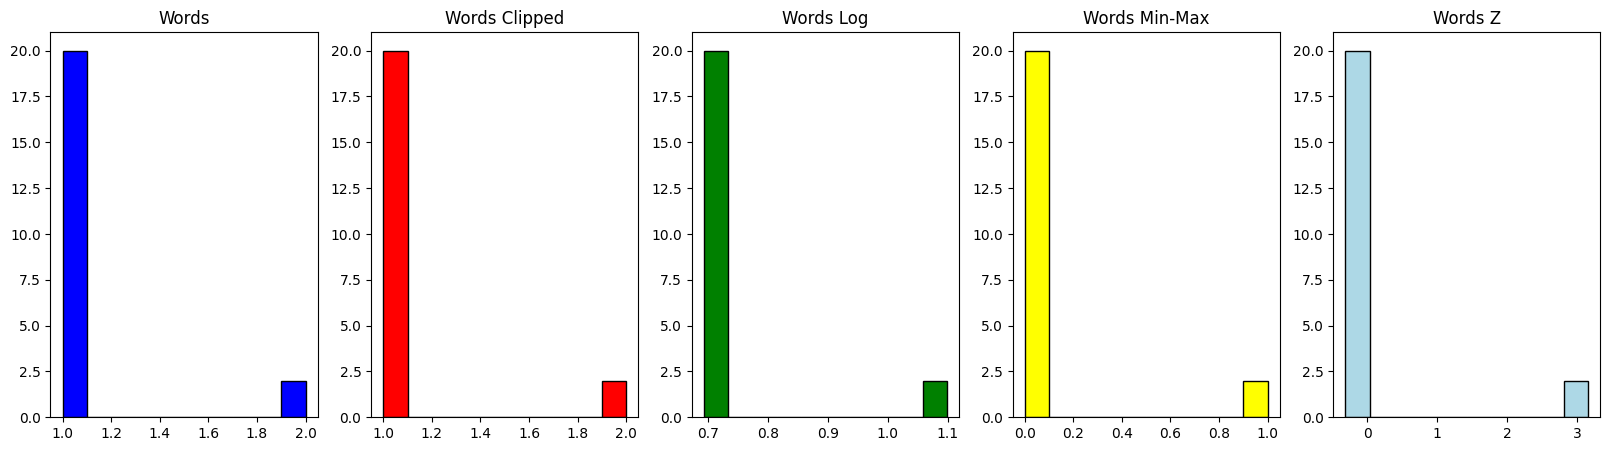

In [53]:
sentenceNo = random.randint(0,len(sentences)-1)
sentence = sentences[sentenceNo]
print(sentence)
words = word_tokenize(sentence)
words_alpha = [word for word in words if word.isalpha()]
counts = Counter(words_alpha)

freq_values = np.array(list(counts.values()))

min_val = freq_values.min()
max_val = freq_values.max()

if max_val - min_val == 0:
    wordsScale01 = np.zeros(len(freq_values))
else:
    wordsScale01 = np.array([(v - min_val) / (max_val - min_val) for v in freq_values])

mean_val = freq_values.mean()
std_val = freq_values.std()

if std_val == 0:
    wordsZ = np.zeros(len(freq_values))
else:
    wordsZ = np.array([(v - mean_val) / std_val for v in freq_values])

wordsLog = np.array([np.log1p(v) for v in freq_values])

wordsClipped = np.array([min(v,2) for v in freq_values])

fig, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1,5, figsize=(20,5))

ax1.hist(counts.values(), color='blue', edgecolor='black')
ax1.set_title("Words")

ax2.hist(wordsClipped, color='red', edgecolor='black')
ax2.set_title("Words Clipped")

ax3.hist(wordsLog, color='green', edgecolor='black')
ax3.set_title("Words Log")

ax4.hist(wordsScale01, color='yellow', edgecolor='black')
ax4.set_title("Words Min-Max")

ax5.hist(wordsZ, color='lightblue', edgecolor='black')
ax5.set_title("Words Z")

plt.show()